<html><span style = "font-size: 24px;"><b>Data preperation & modeling Gradient boosting</b></span></html>

Invoer: In de traindata staan de data die gebruikt worden om de gridsearch uit te voeren met Gradient boosting. Er wordt een gridsearch gedaan op de traindata. De gridsearch en het model worden allemaal opgeslagen in een pipeline.
Uitvoer: Prestatiematen met de beste combinatie uit de gridsearch zijn voortgekomen. Daarnaast wordt de AUC-score weergegeven en de verdeling van de churn.


In [ ]:
"""
@
Auteurs:        Jeffrey Jason Boekstaaf, Tim Paulus van Croimvort en Haydar Eryörük
Studentnummers: 500460365, 500916516 en 500910901
Datum:          23-04-2026
Vak:            Beroepsproject 3.4
Opleiding:      Toegepaste Wiskunde & Data Science
School:         Hogeschool van Amsterdam
"""

import csv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn import ensemble
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, f1_score, precision_score, recall_score, RocCurveDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# De data waarop getraind wordt.
data = pd.read_csv("data_train.csv", sep = ',')


In [ ]:
# numerieke kolommen en categorische kolommen waarbij het referentie niveau gedropt wordt.
numcols = ['Call Failure','Subscription Length','Seconds of Use','Frequency of use','Frequency of SMS']
faccols = ['Age Group','Complaints']
droplevels = [1,0]

# columntransformer voor de datapreperatie fase.
dataprep_GB = ColumnTransformer([
    ('numeriek', StandardScaler(), numcols),
    ('categorisch', OneHotEncoder(drop = droplevels, sparse_output = False), faccols),
], remainder = 'drop', verbose_feature_names_out = False)

dataprep_GB.set_output(transform = 'pandas')
dataprep_GB


In [2]:
# De churn wordt uit de traindata gelaten.
train = data.drop(columns = ['Churn'])
Y = data['Churn']


In [ ]:
# Het model wordt meegegeven aan de pipeline om gebruikt te worden in de evaluation en deployment.
model_GB = Pipeline([('preprocessing', dataprep_GB),
                    ('modelGB', ensemble.GradientBoostingClassifier(
                    min_samples_split = 5,
                    loss = "log_loss",
                    n_estimators = 2000,
                    max_depth = 10,
                    learning_rate = 10))])
model_GB.fit(train, Y)


In [ ]:
# We slaan de pipeline op als een Pickl-bestand.
with open('pipelineGB.pkl', 'wb') as file:
    pickle.dump(model_GB, file)


In [ ]:
# Gridsearch voor gradient boosting met willekeurig gekozen waarden.
gridsearch_GB = GridSearchCV(
    estimator = ensemble.GradientBoostingClassifier(min_samples_split = 5, loss = "log_loss"), 
    param_grid = [{
        "n_estimators" : [2000, 3000, 4000, 5000, 6000],
        "max_depth": [10, 11, 12, 13, 14], 
        "learning_rate": [0.01, 0.1, 1, 10]}],
    scoring = 'accuracy',
    verbose = 2)

gridsearch_GB.fit(train, Y)

# Na de gridsearch met deze parameters laten zien welke combinatie het beste is.
gridsearch_GB.best_estimator_


In [ ]:
# We slaan de Gridsearch op als een Pickl-bestand.
with open('gridsearchGB.pkl', 'wb') as file:
    pickle.dump(gridsearch_GB, file)


In [13]:
# Uit de gridsearch zijn deze parameters als de beste samenstelling gekomen en daarom dienen zij hier meegegeven te worden.
model_GB = GradientBoostingClassifier(n_estimators = 2000, learning_rate = 0.1, max_depth = 11, random_state = 0).fit(train, Y)


In [14]:
# Hier wordt het voorspellen op de validatiedata gedaan.
predicted = model_GB.predict(train)


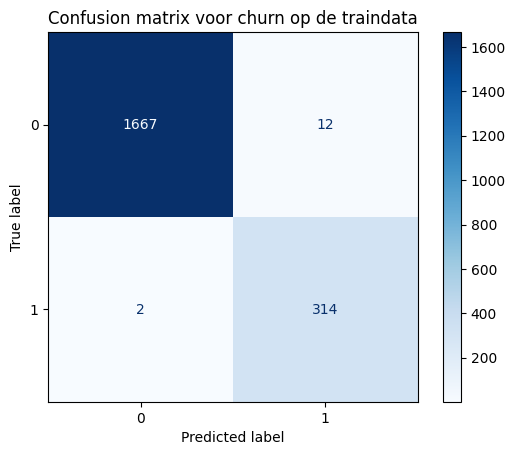

In [15]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(Y, predicted, cmap = 'Blues')
plt.title("Confusion matrix voor churn op de traindata")
plt.show()


Hierboven is er te zien dat er (12 + 2) 14 miskwalificaties zijn. 12 klanten zijn voorspeld door dit model dat diegenen willen overstappen, terwijl diegenen dat niet hebben gedaan. 2 klanten zijn voorspeld door dit model dat dienegen niet willen overstappen, terwijl zij wel zijn overgestapd.
De andere klanten zijn wel goed voorspeld en daarvan zijn 314 die wel voorspeld zijn om over te stappen en zijn overgestapt. Deze groep is de een na grootste groep. De grootste groep zijn 1.667 klanten die niet zijn overgestapt en zijn voorspeld door het model dat diegenen ook niet willen overstappen.


In [16]:
# Hier worden de accuracy, f1, precision en recall scores berekend en gegeven.
acc = round(accuracy_score(Y, predicted), 2)
rec = round(recall_score(Y, predicted), 2)
pre = round(precision_score(Y, predicted), 2)
fsco = round(f1_score(Y, predicted), 2)
table = {"Name": ["Accuracy", "Recall", "Precision", "F1-score"],
        "Value": [acc, rec, pre, fsco]}
df = pd.DataFrame(table)
df


,Name,Value
0,Accuracy,0.99
1,Recall,0.99
2,Precision,0.96
3,F1-score,0.98


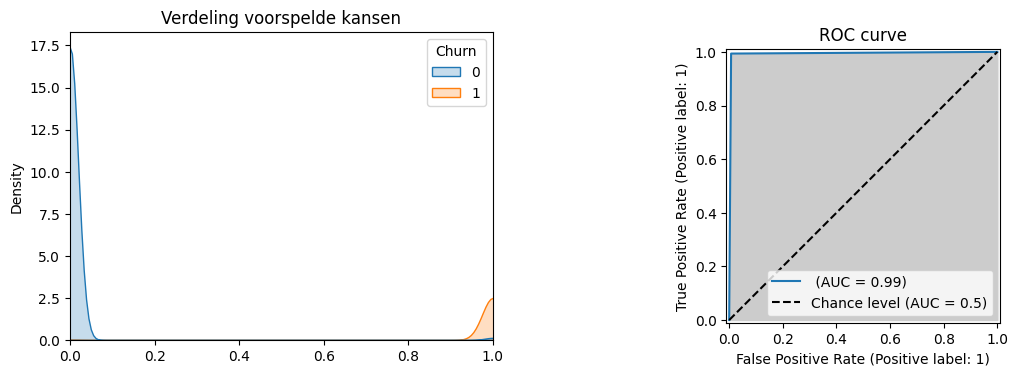

In [17]:
# Verdeling van de voorspelde kansen.
plt.figure(figsize = (12, 4))
plt.subplot(1, 2, 1)
sns.kdeplot(data = pd.DataFrame(Y), x = predicted[:], hue = 'Churn', fill = True)
plt.xlim(0, 1)
plt.title('Verdeling voorspelde kansen')

# ROC-curve
ax = plt.subplot(1, 3, 3)
roc = RocCurveDisplay.from_predictions(
    Y, 
    predicted[:], 
    name = '', 
    plot_chance_level = True,
    ax = ax)
plt.fill_between(roc.fpr, roc.tpr, color = '0.8')
plt.title('ROC curve')
plt.show()


In de figuur hierboven zijn 2 plots weergegeven, waarbij bij de eerste plot de verdeling van de voorspelde kansen voor churn weergeeft en de laatste plot een weergave is van de ROC-curve.
Hierbij geldt voor de eerste plot dat voor een waarde van Churn is 0 geldt dat het model voorspelt dat de klant het abonnement wil opzeggen en voor een waarde van Churn 1 de klant het abonnement wil opgezeggen.